<a href="https://colab.research.google.com/github/marcinwolter/MachineLearning-KISD-2026/blob/main/lecture7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>




#**<font color = "red">Introduction to machine learning</font>**

**Lecture 7**

##**<font color = "green">Stable Diffusion generator network</font>**
##**<font color = "green">Reinforcement learning</font>**


*15 April 2026*


---

*Marcin Wolter, IFJ PAN*

*e-mail: marcin.wolter@ifj.edu.pl*


---
</center>

#<font color='green'>**Program for today:**



* ###  <font color='red'>Stable Diffusion generation algorithm: another method to generate artificial images.
* ###  <font color='red'>Reinforcement learning: how to train a robot?

<br>


**As always all slides are here:**

*https://github.com/marcinwolter/MachineLearning-KISD-2026*

<br>






---



---



---





---

---

# <font color=green> **Stable diffusion generator**



---



---



Stable Diffusion is a deep learning image generatition model **released in 2022** (very new!!!) based on diffusion techniques. It is considered to be a part of the ongoing artifical intelligence boom.

Stable Diffusion, originated from a project called Latent Diffusion, developed by researchers at Ludwig Maximilian University in Munich and Heidelberg University. 4 of the original 5 authors (Robin Rombach, Andreas Blattmann, Patrick Esser and Dominik Lorenz) later joined Stability AI and released subsequent versions of Stable Diffusion.

*Source: wikipedia*


### Very nice tutorial with examples:
https://scholar.harvard.edu/binxuw/classes/machine-learning-scratch/materials/stable-diffusion-scratch

With more mathematical formalism:

https://lilianweng.github.io/posts/2021-07-11-diffusion-models/

# <font color=green> **Quick Overview of Diffusion Models**






To understand how diffusion models work, let’s first look at how they are trained, which is done in a slightly nonintuitive way.

* Begin by applying noise to an image repeatedly, which creates a “Markov chain” of images. In such a way, we are able to get some number *T* of repeatedly more noisy images from a singular original image.

* The model learns to predict the exact noise that was applied at a certain time step, and we can use its output to “denoise” the image at that time step.

* This effectively allows us to go from image T to image T-1 (backward in noise adding chain). The model is trained by giving it the image with noise applied at some time T, and the time T itself, and the output is what **noise** was applied to bring it from time T-1 to T!

* **Image generation**: once such a model is trained, we can **repeatedly apply it to random noise** to produce a new image.

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/StableDiffusion.jpg' width=800px>

###**UNet Model**

* **UNet** architecture model is commonly used to predict the noise at each time step.
* This is a type of architecture that repeatedly applies convolutional layers, pooling layers, and skip connections to first downscale an image but increase depth (feature maps), and then transposed convolutions are used to up-sample the feature maps back to the original image dimensions (a little similar to autoencoder).

**To explain U-Net in one sentence, it would be that U-Net is like an encoder-decoder for images, but with skip connections to make sure fine details are not lost. U-Net are used often in many segmentation tasks, and in recent years have made their ways onto image generation tasks as well.**

*For more Unet info see for example:*

*https://towardsdatascience.com/understanding-u-net-61276b10f360*


<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/Unet.webp' width=800px>

##**Text**

How to add the text factor into this?

When training our model, we not only train it to diffuse images (or, more accurately the latent space representations of these images produced by our first model), we also train it to understand the text and use to generate these images.

This is because “cross attention”, the mechanism which allows the model to selectively focus on certain text features or aspects, is built into the model itself.
Our Denoising UNet is fed the text and some random noise (both encoded), and its final output is compared to the original image. The model both learns to use the text effectively and denoise effectively at the same time.

<img src='https://upload.wikimedia.org/wikipedia/commons/f/f6/Stable_Diffusion_architecture.png' width=600px>

#<font color="green"> **Example of stable diffusion code**

Code adapted from: https://github.com/huggingface/diffusion-models-class/blob/main/unit1/01_introduction_to_diffusers.ipynb

# Introduction to 🤗 Diffusers

![diffusers_library](https://github.com/huggingface/diffusers/raw/main/docs/source/en/imgs/diffusers_library.jpg)

In this notebook, you'll train your first diffusion model to **generate images of cute butterflies 🦋.** Along the way, you'll learn about the core components of the 🤗 Diffusers library, which will provide a good foundation for the more advanced applications that we'll cover later in the course.

Let's dive in!

## What You Will Learn

In this notebook you will:

- See a powerful custom diffusion model pipeline in action (with information on how to make your own version)
- Create your own mini pipeline by:
  - Recapping the core ideas behind diffusion models
  - Loading in data from the Hub for training
  - Exploring how we add noise to this data with a scheduler
  - Creating and training the UNet model
  - Putting the pieces together into a working pipeline


## Step 1: Setup

Finally, let's import the libraries we'll be using and define a few convenience functions which we'll use later in the notebook:

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image


def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0).clip(0, 1) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OK, we're all set!

Run the following cell to install the diffusers library as well as a few other requirements:

In [2]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow==9.0.0

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


## MVP (Minimum Viable Pipeline)

The core API of 🤗 Diffusers is divided into three main components:
1. **Pipelines**: high-level classes designed to rapidly generate samples from popular trained diffusion models in a user-friendly fashion.
2. **Models**: popular architectures for training new diffusion models, *e.g.* [UNet](https://arxiv.org/abs/1505.04597).
3. **Schedulers**: various techniques for generating images from noise during *inference* as well as to generate noisy images for *training*.



We're training from scratch with a small data sample (1000 images only). Speaking of training, recall from the introduction to this unit that training a diffusion model looks something like this:


1.   Load in some images from the training data
2.   Add noise, in different amounts.
3.   Feed the noisy versions of the inputs into the model
4.   Evaluate how well the model does at denoising these inputs
5.   Use this information to update the model weights, and repeat

We'll explore these steps one by one in the next few sections until we have a complete training loop working, and then we'll explore how to sample from the trained model and how to package everything up into a pipeline for easy sharing. Let's begin with the data...

## Step 2: Download a training dataset

For this example, we'll use a dataset of images from the Hugging Face Hub. Specifically, [this collection of 1000 butterfly pictures](https://huggingface.co/datasets/huggan/smithsonian_butterflies_subset). This is a very small dataset, so we've also included commented out lines for a few larger options.

In [3]:
!pip install datasets

In [4]:
import torchvision
from datasets import load_dataset
from torchvision import transforms

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

# Or load images from a local folder
# dataset = load_dataset("imagefolder", data_dir="path/to/folder")

# We'll train on 32-pixel square images, but you can try larger sizes too
image_size = 32
# You can lower your batch size if you're running out of GPU memory
batch_size = 64

# Define data augmentations
preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


We can grab a batch of images and view some of them like so:

X shape: torch.Size([8, 3, 32, 32])


/tmp/ipykernel_3931/1456380996.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


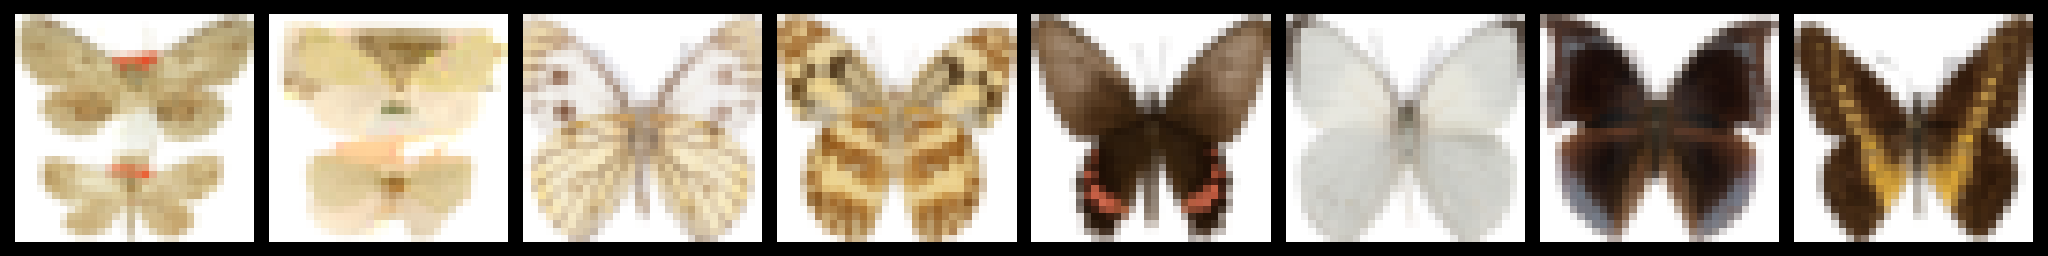

In [5]:
xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 256, 256), resample=Image.NEAREST)

We're sticking to a small dataset with 32 pixel images to keep training times manageable in this notebook.

## Step 3: Define the Scheduler

Our plan for training is to take these input images and add noise to them, then feed the noisy images to the model. And during inference, we will use the model predictions to iteratively remove noise. In `diffusers`,  these processes are both handled by the **scheduler**.

The noise schedule determines how much noise is added at different timesteps. Here's how we might create a scheduler using the default settings for 'DDPM' training and sampling (based on the paper ["Denoising Diffusion Probabilistic Models"](https://arxiv.org/abs/2006.11239)):

In [6]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

The DDPM paper describes a corruption process that adds a small amount of noise for every 'timestep'. Given $x_{t-1}$ for some timestep, we can get the next (slightly more noisy) version $x_t$ with:<br><br>

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$<br><br>


That is, we take $x_{t-1}$, scale it by $\sqrt{1 - \beta_t}$ and add noise scaled by $\beta_t$. This $\beta$ is defined for every t according to some schedule, and determines how much noise is added per timestep. Now, we don't necessarily want to do this operation 500 times to get $x_{500}$ so we have another formula to get $x_t$ for any t given $x_0$: <br><br>

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, {(1 - \bar{\alpha}_t)} \mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$ and $\alpha_i = 1-\beta_i$<br><br>

The maths notation always looks scary! Luckily the scheduler handles all that for us. We can plot $\sqrt{\bar{\alpha}_t}$ (labelled as `sqrt_alpha_prod`) and $\sqrt{(1 - \bar{\alpha}_t)}$ (labelled as `sqrt_one_minus_alpha_prod`) to view how the input (x) and the noise are scaled and mixed across different timesteps:

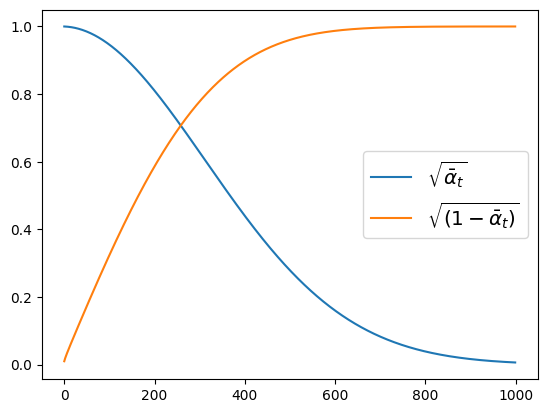

In [7]:
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

**Exercise:** You can explore how this plot changes with different settings for beta_start, beta_end and beta_schedule by swapping in one of the commented-out options here:

In [8]:
# One with too little noise added:
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.004)
# The 'cosine' schedule, which may be better for small image sizes:
# noise_scheduler = DDPMScheduler(num_train_timesteps=1000, beta_schedule='squaredcos_cap_v2')

Whichever scheduler you've chosen, we can now use it to add noise in different amounts using the `noise_scheduler.add_noise` function like so:

Noisy X shape torch.Size([8, 3, 32, 32])


/tmp/ipykernel_3931/1456380996.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


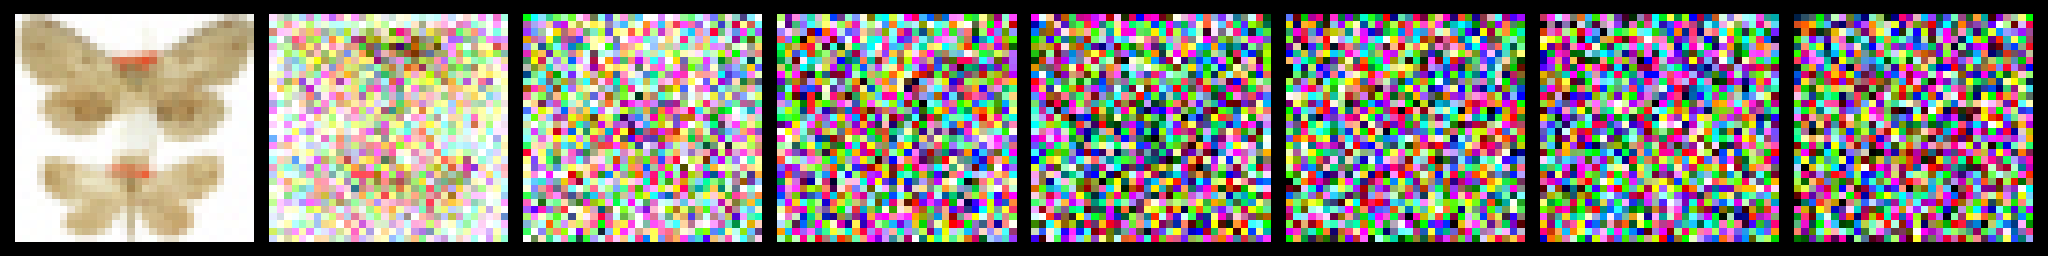

In [9]:
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)
show_images(noisy_xb).resize((8 * 256, 256), resample=Image.NEAREST)

Again, explore the effect of using different noise schedules and parameters here. [This video](https://www.youtube.com/watch?v=fbLgFrlTnGU) does a great job explaining some of the maths above in more detail, and is a great introduction to some of these concepts.

## Step 4: Define the Model

Now we come to the core component: the model itself.

Most diffusion models use architectures that are some variant of a [U-net](https://arxiv.org/abs/1505.04597) and that's what we'll use here.

![](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/unet-model.png)

In a nutshell:
- the model has the input image go through several blocks of ResNet layers, each of which halves the image size by 2
- then through the same number of blocks that upsample it again.
- there are skip connections linking the features on the downsample path to the corresponding layers in the upsample path.

A key feature of this model is that it predicts images of the same size as the input, which is exactly what we need here.

Diffusers provides us a handy `UNet2DModel` class which creates the desired architecture in PyTorch.

Let's create a U-net for our desired image size.
Note that `down_block_types` correspond to the downsampling blocks (green on the diagram above), and `up_block_types` are the upsampling blocks (red on the diagram):

In [10]:
from diffusers import UNet2DModel

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=3,  # the number of input channels, 3 for RGB images
    out_channels=3,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device);

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


When dealing with higher-resolution inputs you may want to use more down and up-blocks, and keep the attention layers only at the lowest resolution (bottom) layers to reduce memory usage.

We can check that passing in a batch of data and some random timesteps produces an output the same shape as the input data:

In [11]:
with torch.no_grad():
    model_prediction = model(noisy_xb, timesteps).sample
model_prediction.shape

torch.Size([8, 3, 32, 32])

In the next section we'll see how to train this model.

## Step 5: Create a Training Loop

Time to train! Below is a typical optimization loop in PyTorch, where we run through the data batch by batch and update the parameters of our model each step using an optimizer - in this case the AdamW optimizer with a learning rate of 0.0004.

For each batch of data, we
- Sample some random timesteps
- Noise the data accordingly
- Feed the noisy data through the model
- Compare the model predictions with the target (i.e. the noise in this case) using mean squared error as our loss function
- Update the model parameters via `loss.backward()` and `optimizer.step()`

During this process we also log the losses over time for later plotting.

NB: This code takes some minutes to run...

The [official diffusers training example](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/training_example.ipynb) trains a larger model on this dataset at higher resolution, and is a good reference for a slightly bigger training loop:

In [12]:
from diffusers import DDPMPipeline

In [13]:
# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

losses = []

for epoch in range(30):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch["images"].to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 1 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

    # Plot the images
    #if (epoch + 1) % 1 == 0:
    #    image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)
    #    pipeline_output = image_pipe()
    #    show_images(pipeline_output.images[0]).resize((256, 256), resample=Image.NEAREST)

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:1, loss: 0.4503950132057071
Epoch:2, loss: 0.2153016310185194
Epoch:3, loss: 0.1728131864219904
Epoch:4, loss: 0.16241244599223137
Epoch:5, loss: 0.15517771802842617
Epoch:6, loss: 0.14322747848927975
Epoch:7, loss: 0.13181772828102112
Epoch:8, loss: 0.12401714688166976
Epoch:9, loss: 0.1252856026403606
Epoch:10, loss: 0.12159842066466808
Epoch:11, loss: 0.11330783739686012
Epoch:12, loss: 0.11068041808903217
Epoch:13, loss: 0.11142272455617785
Epoch:14, loss: 0.10005531553179026
Epoch:15, loss: 0.10211427789181471
Epoch:16, loss: 0.09315610490739346
Epoch:17, loss: 0.09628162067383528
Epoch:18, loss: 0.09658471494913101
Epoch:19, loss: 0.08980684401467443
Epoch:20, loss: 0.08577708480879664
Epoch:21, loss: 0.08355680014938116
Epoch:22, loss: 0.08257119730114937
Epoch:23, loss: 0.08816300379112363
Epoch:24, loss: 0.0871904999949038
Epoch:25, loss: 0.0756290266290307
Epoch:26, loss: 0.0829688641242683
Epoch:27, loss: 0.0786206538323313
Epoch:28, loss: 0.08295325795188546
Epoch:29,

Plotting the loss, we see that the model rapidly improves initially and then continues to get better at a slower rate (which is more obvious if we use a log scale as shown on the right):

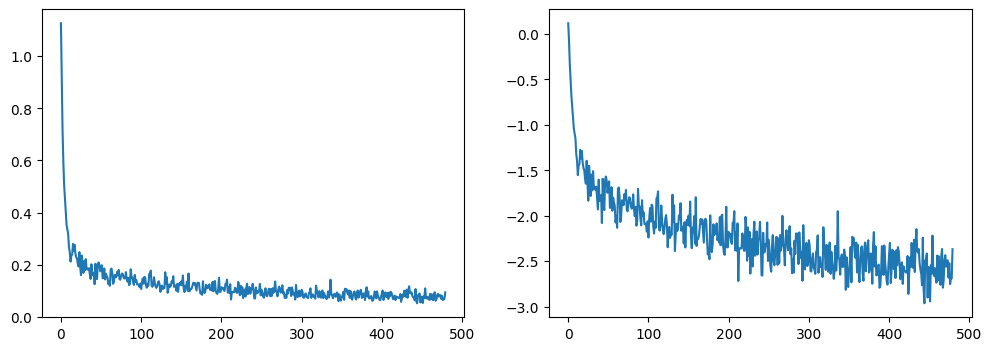

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

As an alternative to running the training code above, you can use the model from the pipeline like so:

In [15]:
# Uncomment to instead load the model I trained earlier:
# model = butterfly_pipeline.unet

## Step 6: Generate Images

How do we get images with this model?

### Option 1: Creating a pipeline:

In [16]:
from diffusers import DDPMPipeline

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler)

  0%|          | 0/1000 [00:00<?, ?it/s]

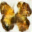

In [17]:
pipeline_output = image_pipe()
pipeline_output.images[0]

We can save a pipeline to a local folder like so:

In [18]:
image_pipe.save_pretrained("my_pipeline")

Inspecting the folder contents:

In [19]:
!ls my_pipeline/

model_index.json  scheduler  unet


The `scheduler` and `unet` subfolders contain everything needed to re-create those components. For example, inside the `unet` folder you'll find the model weights (`diffusion_pytorch_model.bin`) alongside a config file which specifies the UNet architecture.

In [20]:
!ls my_pipeline/unet/

config.json  diffusion_pytorch_model.safetensors


Together, these files contain everything needed to recreate the pipeline.

### Option 2: Writing a Sampling Loop

If you inspect the forward method of the pipeline you'll be able to see what is happening when we run `image_pipe()`:

In [21]:
# image_pipe.forward

We begin with random noise, and run through the scheduler timesteps from most to least noisy, removing a small amount of noise each step based on the model prediction:

/tmp/ipykernel_3931/1456380996.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))


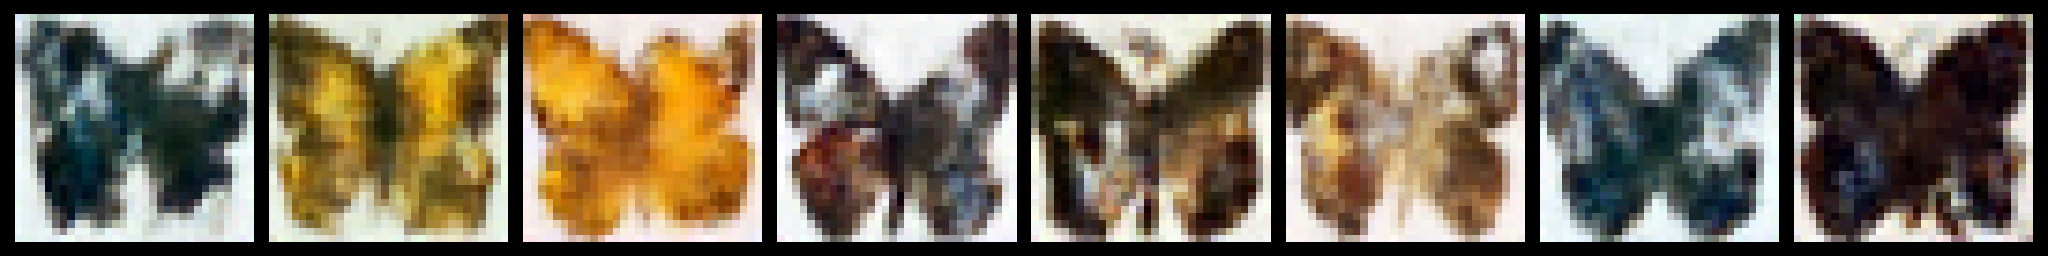

In [22]:
# Random starting point (8 random images):
sample = torch.randn(8, 3, 32, 32).to(device)

for i, t in enumerate(noise_scheduler.timesteps):

    # Get model pred
    with torch.no_grad():
        residual = model(sample, t).sample

    # Update sample with step
    sample = noise_scheduler.step(residual, t, sample).prev_sample

show_images(sample).resize((8 * 256, 256), resample=Image.NEAREST)



---



---



---



# **Faces generation**

The same code (updated to generate 128x128 images) used to generate faces:

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/original.png' width=800px>

*Original photos*

<img src='https://raw.githubusercontent.com/marcinwolter/MachineLearning-KISD-2024/main/images/generated.png' width=800px>

*Generated photos*

Code: https://github.com/marcinwolter/MachineLearning-KISD-2026/blob/main/01_intro.nbconvert.ipynb

Time: about 12 h.



---



---



---



# <font color='green'> **Reinforcement learning**

##**Definition**
Reinforcement Learning (RL) is the science of decision making. It is about learning the optimal behavior in an environment to obtain maximum reward. This optimal behavior is learned through interactions with the environment and observations of how it responds, similar to children exploring the world around them and learning the actions that help them achieve a goal.

In the absence of a supervisor, the learner must independently discover the sequence of actions that maximize the reward. This discovery process is akin to a trial-and-error search. The quality of actions is measured by not just the immediate reward they return, but also the delayed reward they might fetch. As it can learn the actions that result in eventual success in an unseen environment without the help of a supervisor, reinforcement learning is a very powerful algorithm.

##**How Does Reinforcement Learning Work?**
The Reinforcement Learning problem involves an agent exploring an unknown environment to achieve a goal. RL is based on the hypothesis that all goals can be described by the maximization of expected cumulative reward. The agent must learn to sense and perturb the state of the environment using its actions to derive maximal reward. The formal framework for RL borrows from the problem of optimal control of Markov Decision Processes (MDP).

The main elements of an RL system are:

1. The agent or the learner
2. The environment the agent interacts with
3. The policy that the agent follows to take actions
4. The reward signal that the agent observes upon taking actions

A useful abstraction of the reward signal is the value function, which faithfully captures the ‘goodness’ of a state. While the reward signal represents the immediate benefit of being in a certain state, the value function captures the cumulative reward that is expected to be collected from that state on, going into the future. The objective of an RL algorithm is to discover the action policy that maximizes the average value that it can extract from every state of the system.

<img src='https://images.synopsys.com/is/image/synopsys/reinforcement-learningV1-02?qlt=82&wid=1200&ts=1680107783898&$responsive$&fit=constrain&dpr=off' width=500px>

## **Examples of Reinforcement Learning**
Any real-world problem where an agent must interact with an uncertain environment to meet a specific goal is a potential application of RL. Here are a few RL success stories:

1. **Robotics.** Robots with pre-programmed behavior are useful in structured environments, such as the assembly line of an automobile manufacturing plant, where the task is repetitive in nature. In the real world, where the response of the environment to the behavior of the robot is uncertain, pre-programming accurate actions is nearly impossible. In such scenarios, RL provides an efficient way to build general-purpose robots. It has been successfully applied to robotic path planning, where a robot must find a short, smooth, and navigable path between two locations, void of collisions and compatible with the dynamics of the robot.

2. **AlphaGo.** One of the most complex strategic games is a 3,000-year-old Chinese board game called Go. Its complexity stems from the fact that there are 10^270 possible board combinations, several orders of magnitude more than the game of chess. In 2016, an RL-based Go agent called AlphaGo defeated the greatest human Go player. Much like a human player, it learned by experience, playing thousands of games with professional players. The latest RL-based Go agent has the capability to learn by playing against itself, an advantage that the human player doesn’t have.

3. **Autonomous Driving.** An autonomous driving system must perform multiple perception and planning tasks in an uncertain environment. Some specific tasks where RL finds application include vehicle path planning and motion prediction. Vehicle path planning requires several low and high-level policies to make decisions over varying temporal and spatial scales. Motion prediction is the task of predicting the movement of pedestrians and other vehicles, to understand how the situation might develop based on the current state of the environment.

<h2><strong>How Actor-Critic works:</strong></h2>
<p>Imagine you play a video game with a friend that provides you some feedback. You're the Actor, and your friend is the Critic:</p>
<p><img class="img-fluid" style="display: block; margin-left: auto; margin-right: auto;" src="https://pylessons.com/media/Tutorials/Reinforcement-learning-tutorial/A2C-reinforcement-learning/09_A2C-reinforcement-learning.png" alt="" width="949" height="534" />

In the beginning, you don't know how to play, so you try some action randomly. The Critic observes your action and provides feedback.
<p>In the Actor-Critic Methods:</p>
<ul>
<li>The "Critic" estimates the value function. This could be the action-value (the Q value) or state-value (the V value).</li>
<li>Critic: Q-learning algorithm that critiques the action that the Actor selected, providing feedback on how to adjust. It can take advantage of efficiency tricks in Q-learning, such as memory replay.</li>
</ul>
<p>We update both the Critic network and the Value network at each update step.</p>
<p>Intuitively, this means how better it is to take a specific action than the average general action at the given state. So, using the Value function as the baseline function, we subtract the Q value term with the Value.

# Actor Critic Method

**Author:** [Apoorv Nandan](https://twitter.com/NandanApoorv)<br>
Modified by Marcin Wolter<br>
**Date created:** 2020/05/13<br>
**Last modified:** 2023/04/16<br>
**Description:** Implement Actor Critic Method in CartPole environment.

## Introduction

This script shows an implementation of Actor Critic method on CartPole-V0 environment.

### Actor Critic Method

As an agent takes actions and moves through an environment, it learns to map
the observed state of the environment to two possible outputs:

1. Recommended action: A probability value for each action in the action space.
   The part of the agent responsible for this output is called the **actor**.
2. Estimated rewards in the future: Sum of all rewards it expects to receive in the
   future. The part of the agent responsible for this output is the **critic**.

Agent and Critic learn to perform their tasks, such that the recommended actions
from the actor maximize the rewards.

### CartPole-V1

A pole is attached to a cart placed on a frictionless track. The agent has to apply
force to move the cart. It is rewarded for every time step the pole
remains upright. The agent, therefore, must learn to keep the pole from falling over.

### References

- [CartPole](http://www.derongliu.org/adp/adp-cdrom/Barto1983.pdf)
- [CartPole in GYM](https://www.gymlibrary.dev/environments/classic_control/cart_pole/ )
- [Actor Critic Method](https://hal.inria.fr/hal-00840470/document)


# **Cart Pole**
<figure class="align-default" id="id1">
<a class="reference internal image-reference" href="https://www.gymlibrary.dev/_images/cart_pole.gif"><img alt="https://www.gymlibrary.dev/_images/cart_pole.gif" src="https://www.gymlibrary.dev/_images/cart_pole.gif" style="width: 200px;" /></a>
</figure>
<p>This environment is part of the <a href='..'>Classic Control environments</a>. Please read that page first for general information.</p>
<div class="table-wrapper colwidths-auto docutils container">
<table class="docutils align-default">
<thead>
<tr class="row-odd"><th class="head"><p></p></th>
<th class="head"><p></p></th>
</tr>
</thead>
<tbody>
<tr class="row-even"><td><p>Action Space</p></td>
<td><p>Discrete(2)</p></td>
</tr>
<tr class="row-odd"><td><p>Observation Shape</p></td>
<td><p>(4,)</p></td>
</tr>
<tr class="row-even"><td><p>Observation High</p></td>
<td><p>[4.8   inf 0.42  inf]</p></td>
</tr>
<tr class="row-odd"><td><p>Observation Low</p></td>
<td><p>[-4.8   -inf -0.42  -inf]</p></td>
</tr>
<tr class="row-even"><td><p>Import</p></td>
<td><p><code class="docutils literal notranslate"><span class="pre">gym.make(&quot;CartPole-v1&quot;)</span></code></p></td>
</tr>
</tbody>
</table>
</div>
<section id="description">
<h2>Description</h2>
<p>This environment corresponds to the version of the cart-pole problem described by Barto, Sutton, and Anderson in
<a class="reference external" href="https://ieeexplore.ieee.org/document/6313077">“Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem”</a>.
A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track.
The pendulum is placed upright on the cart and the goal is to balance the pole by applying forces
in the left and right direction on the cart.</p>
</section>
<section id="action-space">
<h2>Action Space</h2>
<p>The action is a <code class="docutils literal notranslate"><span class="pre">ndarray</span></code> with shape <code class="docutils literal notranslate"><span class="pre">(1,)</span></code> which can take values <code class="docutils literal notranslate"><span class="pre">{0,</span> <span class="pre">1}</span></code> indicating the direction
of the fixed force the cart is pushed with.</p>
<div class="table-wrapper colwidths-auto docutils container">
<table class="docutils align-default">
<thead>
<tr class="row-odd"><th class="head"><p>Num</p></th>
<th class="head"><p>Action</p></th>
</tr>
</thead>
<tbody>
<tr class="row-even"><td><p>0</p></td>
<td><p>Push cart to the left</p></td>
</tr>
<tr class="row-odd"><td><p>1</p></td>
<td><p>Push cart to the right</p></td>
</tr>
</tbody>
</table>
</div>
<p><strong>Note</strong>: The velocity that is reduced or increased by the applied force is not fixed and it depends on the angle
the pole is pointing. The center of gravity of the pole varies the amount of energy needed to move the cart underneath it</p>
</section>
<section id="observation-space">
<h2>Observation Space</h2>
<p>The observation is a <code class="docutils literal notranslate"><span class="pre">ndarray</span></code> with shape <code class="docutils literal notranslate"><span class="pre">(4,)</span></code> with the values corresponding to the following positions and velocities:</p>
<div class="table-wrapper colwidths-auto docutils container">
<table class="docutils align-default">
<thead>
<tr class="row-odd"><th class="head"><p>Num</p></th>
<th class="head"><p>Observation</p></th>
<th class="head"><p>Min</p></th>
<th class="head"><p>Max</p></th>
</tr>
</thead>
<tbody>
<tr class="row-even"><td><p>0</p></td>
<td><p>Cart Position</p></td>
<td><p>-4.8</p></td>
<td><p>4.8</p></td>
</tr>
<tr class="row-odd"><td><p>1</p></td>
<td><p>Cart Velocity</p></td>
<td><p>-Inf</p></td>
<td><p>Inf</p></td>
</tr>
<tr class="row-even"><td><p>2</p></td>
<td><p>Pole Angle</p></td>
<td><p>~ -0.418 rad (-24°)</p></td>
<td><p>~ 0.418 rad (24°)</p></td>
</tr>
<tr class="row-odd"><td><p>3</p></td>
<td><p>Pole Angular Velocity</p></td>
<td><p>-Inf</p></td>
<td><p>Inf</p></td>
</tr>
</tbody>
</table>
</div>
<p><strong>Note:</strong> While the ranges above denote the possible values for observation space of each element,
it is not reflective of the allowed values of the state space in an unterminated episode. Particularly:</p>
<ul class="simple">
<li><p>The cart x-position (index 0) can be take values between <code class="docutils literal notranslate"><span class="pre">(-4.8,</span> <span class="pre">4.8)</span></code>, but the episode terminates
if the cart leaves the <code class="docutils literal notranslate"><span class="pre">(-2.4,</span> <span class="pre">2.4)</span></code> range.</p></li>
<li><p>The pole angle can be observed between  <code class="docutils literal notranslate"><span class="pre">(-.418,</span> <span class="pre">.418)</span></code> radians (or <strong>±24°</strong>), but the episode terminates
if the pole angle is not in the range <code class="docutils literal notranslate"><span class="pre">(-.2095,</span> <span class="pre">.2095)</span></code> (or <strong>±12°</strong>)</p></li>
</ul>
</section>
<section id="rewards">
<h2><b>Rewards</b></h2>
<p><b>Since the goal is to keep the pole upright for as long as possible, a reward of <code class="docutils literal notranslate"><span class="pre">+1</span></code> for every step taken,
including the termination step, is allotted. The threshold for rewards is 475 for v1.</b></p>
</section>
<section id="starting-state">
<h2>Starting State</h2>
<p>All observations are assigned a uniformly random value in <code class="docutils literal notranslate"><span class="pre">(-0.05,</span> <span class="pre">0.05)</span></code></p>
</section>
<section id="episode-end">
<h2>Episode End</h2>
<p>The episode ends if any one of the following occurs:</p>
<ol class="arabic simple">
<li><p>Termination: Pole Angle is greater than ±12°</p></li>
<li><p>Termination: Cart Position is greater than ±2.4 (center of the cart reaches the edge of the display)</p></li>
<li><p>Truncation: Episode length is greater than 500 (200 for v0)</p></li>
</ol>
</section>
<section id="arguments">
<h2>Arguments</h2>
<div class="highlight-default notranslate"><div class="highlight"><pre><span></span><span class="n">gym</span><span class="o">.</span><span class="n">make</span><span class="p">(</span><span class="s1">&#39;CartPole-v1&#39;</span><span class="p">)</span>
</pre></div>
</div>
<p>No additional arguments are currently supported.</p>
</section>
</section>

## Setup


In [1]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# from gym import wrappers # Not needed with gymnasium
from gymnasium.wrappers import RecordVideo # Corrected import path
import os
import matplotlib.pyplot as plt
from IPython import display


# Configuration parameters for the whole setup
seed = 42
gamma = 0.99  # Discount factor for past rewards
max_steps_per_episode = 10000
env = gym.make("CartPole-v1", render_mode='rgb_array')  # Create the environment with render_mode
state, _ = env.reset(seed=seed) # env.reset now returns observation and info
eps = np.finfo(np.float32).eps.item()  # Smallest number such that 1.0 + eps != 1.0
print("eps = ",eps)

eps =  1.1920928955078125e-07


In [2]:

# Configuration parameters for the whole setup
seed = 42
gamma = 0.99  # Discount factor for past rewards
max_steps_per_episode = 10000
env = gym.make("CartPole-v1")  # Create the environment  , render_mode='rgb_array'
env.reset(seed=seed)
eps = np.finfo(np.float32).eps.item()  # Smallest number such that 1.0 + eps != 1.0
print("eps = ",eps)

eps =  1.1920928955078125e-07


## Implement Actor Critic network

This network learns two functions:

1. **Actor:** This takes as input the state of our environment and returns a
probability value for each action in its action space.
2. **Critic:** This takes as input the state of our environment and returns
an estimate of total rewards in the future.

In our implementation, they share the initial layer.


In [3]:
num_inputs = 4    # four parameters describing the cart state
num_actions = 2   # move the cart left or right
num_hidden = 128

inputs = layers.Input(shape=(num_inputs,))
common = layers.Dense(num_hidden, activation="relu")(inputs)
action = layers.Dense(num_actions, activation="softmax")(common)
critic = layers.Dense(1)(common)

model = keras.Model(inputs=inputs, outputs=[action, critic])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from gymnasium.wrappers import RecordVideo

def make_video(episode_num, model, base_env_for_video):
    # Define a unique folder for each episode's video
    video_subfolder = f'videos/episode_{episode_num}'
    os.makedirs(video_subfolder, exist_ok=True) # Ensure the directory exists

    # RecordVideo automatically handles rendering
    # Pass the unique subfolder as video_folder
    video_env = RecordVideo(base_env_for_video, video_folder=video_subfolder, episode_trigger=lambda x: True, disable_logger=True)

    steps = 0
    terminated = False
    truncated = False
    state, _ = video_env.reset() # gymnasium.Env.reset returns (observation, info)

    while not terminated and not truncated:
        video_env.render()
        # Predict action probabilities and estimated future rewards
        # from environment state
        state = tf.convert_to_tensor(state)
        state = tf.expand_dims(state, 0)
        action_probs, critic_value = model(state)
        # Sample action from action probability distribution
        action = np.random.choice(num_actions, p=np.squeeze(action_probs))
        state, reward, terminated, truncated, _ = video_env.step(action) # gymnasium.Env.step returns 5 values
        steps += 1

    print("Testing steps: {}: ".format(steps))
    video_env.close()

## Train


In [5]:
# Explicitely install newest numpy version to get the required type bool8
!pip install numpy --upgrade

In [6]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)
huber_loss = keras.losses.Huber()  # see https://keras.io/api/losses/regression_losses/#huber-class
action_probs_history = []
critic_value_history = []
rewards_history = []
running_reward = 0
episode_count = 0

# Ensure the base directory for videos exists
import os
os.makedirs('videos', exist_ok=True)

# Removed continuous VideoRecorder as it's deprecated and problematic with gymnasium.
# We will use make_video for episodic recording during training and at the end.

while True:  # Run until solved

    state, _ = env.reset() # gymnasium.Env.reset returns (observation, info)

    episode_reward = 0
    with tf.GradientTape() as tape:
        for timestep in range(1, max_steps_per_episode):
            # Removed direct env.render() and video.capture_frame() from here.
            # make_video function will handle rendering for specific episodes.

            state = tf.convert_to_tensor(state)
            state = tf.expand_dims(state, 0)

            # Predict action probabilities and estimated future rewards
            # from environment state
            action_probs, critic_value = model(state)
            critic_value_history.append(critic_value[0, 0])

            # Sample action from action probability distribution
            action = np.random.choice(num_actions, p=np.squeeze(action_probs))
            action_probs_history.append(tf.math.log(action_probs[0, action]))

            # Apply the sampled action in our environment
            state, reward, terminated, truncated, _ = env.step(action) # gymnasium.Env.step returns 5 values
            done = terminated or truncated # 'done' combines terminated and truncated for backward compatibility

            rewards_history.append(reward)
            episode_reward += reward

            if done:
                break

        # Update running reward to check condition for solving
        running_reward = 0.05 * episode_reward + (1 - 0.05) * running_reward

        # Calculate expected value from rewards
        # - At each timestep what was the total reward received after that timestep
        # - Rewards in the past are discounted by multiplying them with gamma
        # - These are the labels for our critic
        returns = []
        discounted_sum = 0
        for r in rewards_history[::-1]:
            discounted_sum = r + gamma * discounted_sum
            returns.insert(0, discounted_sum)

        # Normalize
        returns = np.array(returns)
        returns = (returns - np.mean(returns)) / (np.std(returns) + eps)
        returns = returns.tolist()

        # Calculating loss values to update our network
        history = zip(action_probs_history, critic_value_history, returns)
        actor_losses = []
        critic_losses = []
        for log_prob, value, ret in history:
            # At this point in history, the critic estimated that we would get a
            # total reward = `value` in the future. We took an action with log probability
            # of `log_prob` and ended up recieving a total reward = `ret`.
            # The actor must be updated so that it predicts an action that leads to
            # high rewards (compared to critic's estimate) with high probability.
            diff = ret - value
            actor_losses.append(-log_prob * diff)  # actor loss

            # The critic must be updated so that it predicts a better estimate of
            # the future rewards.
            critic_losses.append(
                huber_loss(tf.expand_dims(value, 0), tf.expand_dims(ret, 0))
            )

        # Backpropagation
        loss_value = sum(actor_losses) + sum(critic_losses)
        grads = tape.gradient(loss_value, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Clear the loss and reward history (Corrected Indentation)
    action_probs_history.clear()
    critic_value_history.clear()
    rewards_history.clear()

    # Log details
    episode_count += 1
    if episode_count % 10 == 0:
        template = "running reward: {:.2f} at episode {}"
        print(template.format(running_reward, episode_count))

        # Record a video for this testing episode
        make_video(episode_count, model, gym.make("CartPole-v1", render_mode='rgb_array'))

    if running_reward > 195:  # Condition to consider the task solved
        print("Solved at episode {}!".format(episode_count))
        # The continuous video object 'video' no longer exists here, as it was removed.
        break

running reward: 11.55 at episode 10


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/episode_10 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Testing steps: 27: 
running reward: 24.85 at episode 20


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/episode_20 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Testing steps: 47: 
running reward: 30.06 at episode 30


...

Testing steps: 15: 
running reward: 92.32 at episode 110


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/episode_110 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Testing steps: 102: 
running reward: 127.13 at episode 120


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/episode_120 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Testing steps: 219: 
Solved at episode 128!


In [7]:
import sys
!{sys.executable} -m pip install gymnasium


### **Record video after training**

In [8]:
make_video(episode_count, model, gym.make("CartPole-v1", render_mode='rgb_array')) # Call make_video with updated API

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/episode_128 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Testing steps: 484: 


# **So, we have trained the robot!!!**

###**Film showing the training of a robot:**

[![Blinking LEDs](http://img.youtube.com/vi/n2gE7n11h1Y/0.jpg)](https://www.youtube.com/watch?v=n2gE7n11h1Y "Blinking LEDs")

#<font color='green'> **Summary:**

* <span style="color:#000000">Many new methods were developed recently\.</span>

* <span style="color:#000000">Machine Learning approach becomes to be used not only for classification\, but also for generative tasks\.</span>

* <span style="color:#000000">Each month new application appear\! </span>


# <font color = green> **Next and the last lecture**

* Few words about large language models like chatGPT
* If the time allows we can talk about Mixture Density Network (MDN). It is a neural network that predicts the parameters of a mixture of distributions rather than a single point estimate.